<a href="https://colab.research.google.com/github/moein-13/Python_Programming-A-/blob/main/Football_Soccer_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Fifa 23 Players Data.csv")
df.head()

#df.shape

,Known As,Full Name,Overall,Potential,Value(in Euro),Positions Played,Best Position,Nationality,Image Link,Age,...,LM Rating,CM Rating,RM Rating,LWB Rating,CDM Rating,RWB Rating,LB Rating,CB Rating,RB Rating,GK Rating
0,L. Messi,Lionel Messi,91,91,54000000,RW,CAM,Argentina,https://cdn.sofifa.net/players/158/023/23_60.png,35,...,91,88,91,67,66,67,62,53,62,22
1,K. Benzema,Karim Benzema,91,91,64000000,"CF,ST",CF,France,https://cdn.sofifa.net/players/165/153/23_60.png,34,...,89,84,89,67,67,67,63,58,63,21
2,R. Lewandowski,Robert Lewandowski,91,91,84000000,ST,ST,Poland,https://cdn.sofifa.net/players/188/545/23_60.png,33,...,86,83,86,67,69,67,64,63,64,22
3,K. De Bruyne,Kevin De Bruyne,91,91,107500000,"CM,CAM",CM,Belgium,https://cdn.sofifa.net/players/192/985/23_60.png,31,...,91,91,91,82,82,82,78,72,78,24
4,K. Mbappé,Kylian Mbappé,91,95,190500000,"ST,LW",ST,France,https://cdn.sofifa.net/players/231/747/23_60.png,23,...,92,84,92,70,66,70,66,57,66,21


#Data Cleaning

In [ ]:
df.drop_duplicates(inplace = True)
df.drop(['Known As'] ,  axis = 1 , inplace = True , errors = 'ignore')

df.fillna(0 , inplace = True)

print('After Cleaning our Data Size :')
print(df.shape)


After Cleaning our Data Size :
(18420, 88)


#Feature Engineering

In [ ]:
#Feature - 1
df['Growth_Potential'] = df['Potential'] - df['Overall']

#Feature - 2
exchange_rate_bdt = 130

df['Value_in_BDT'] = df['Value(in Euro)'] * exchange_rate_bdt
df['Value_in_Crore_BDT'] = df['Value_in_BDT'] / 10000000

#Feature - 3
df[['Full Name' , 'Value(in Euro)', 'Value_in_Crore_BDT']].head()



,Full Name,Value(in Euro),Value_in_Crore_BDT
0,Lionel Messi,54000000,702.0
1,Karim Benzema,64000000,832.0
2,Robert Lewandowski,84000000,1092.0
3,Kevin De Bruyne,107500000,1397.5
4,Kylian Mbappé,190500000,2476.5


#Numpy use case


In [ ]:
elite_threshold = np.percentile(df['Overall'] , 95)
print(f"Top 5 % Elite Players Who has Minimum Overall Rating : {elite_threshold} ")


df['Is_Elite'] = np.where(df['Overall'] >= elite_threshold , 'Yes' , 'No')

df[df['Is_Elite'] == 'Yes'] [['Full Name' , 'Overall' , 'Value_in_Corer_BDT']].head(20)

Top 5 % Elite Players Who has Minimum Overall Rating : 77.0 


,Full Name,Overall,Value_in_Corer_BDT
0,Lionel Messi,91,702.0
1,Karim Benzema,91,832.0
2,Robert Lewandowski,91,1092.0
3,Kevin De Bruyne,91,1397.5
4,Kylian Mbappé,91,2476.5
5,Mohamed Salah,90,1501.5
6,Thibaut Courtois,90,1170.0
7,Manuel Neuer,90,175.5
8,C. Ronaldo dos Santos Aveiro,90,533.0
9,Virgil van Dijk,90,1274.0


In [ ]:
df['Wage_in_Crore_BDT'] = (df['Wage(in Euro)'] * 130 ) / 10000000

wage_threshold_bdt = np.percentile(df['Wage_in_Crore_BDT'] , 95 )

print(f"Top 5% highest paid player Weekly Salary : {wage_threshold_bdt}")

top_paid_players = df[df['Wage_in_Crore_BDT'] >= wage_threshold_bdt]

top_paid_players = top_paid_players.sort_values(by = 'Wage_in_Crore_BDT' , ascending = False)
top_paid_players[['Full Name' , 'Wage_in_Crore_BDT' , 'Value_in_Crore_BDT']].head(20)


Top 5% highest paid player Weekly Salary : 0.481


,Full Name,Wage_in_Crore_BDT,Value_in_Crore_BDT
1,Karim Benzema,5.85,832.0
2,Robert Lewandowski,5.46,1092.0
3,Kevin De Bruyne,4.55,1397.5
28,Toni Kroos,4.03,936.0
5,Mohamed Salah,3.51,1501.5
23,Bernardo Mota Carvalho e Silva,3.38,1267.5
6,Thibaut Courtois,3.25,1170.0
24,João Pedro Cavaco Cancelo,3.25,1072.5
30,Antonio Rüdiger,3.25,955.5
10,Harry Kane,3.12,1371.5


#Data Visualization

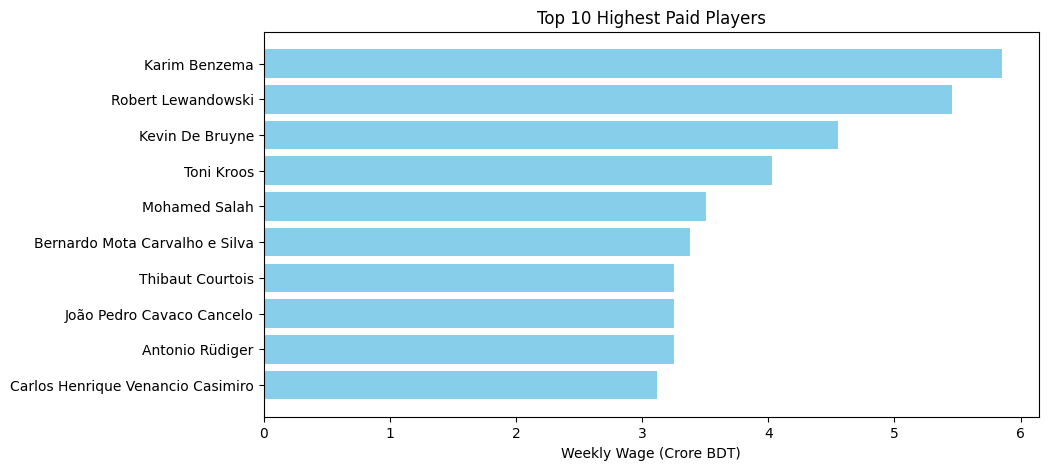

In [ ]:
top_10_wage = df.sort_values(by='Wage_in_Crore_BDT', ascending=False).head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_10_wage['Full Name'], top_10_wage['Wage_in_Crore_BDT'], color='skyblue')
plt.xlabel('Weekly Wage (Crore BDT)')
plt.title('Top 10 Highest Paid Players')
plt.gca().invert_yaxis()
plt.show()

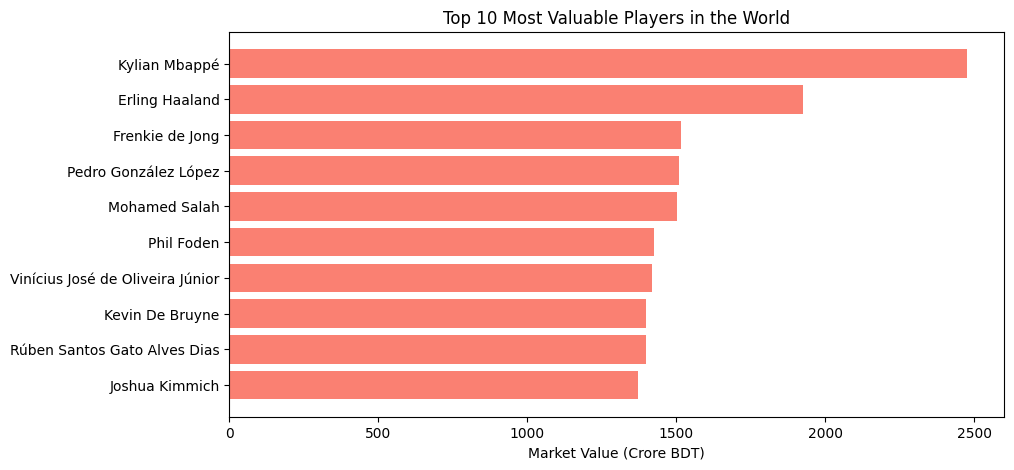

In [ ]:
top_10_value = df.sort_values(by='Value_in_Corer_BDT', ascending=False).head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_10_value['Full Name'], top_10_value['Value_in_Corer_BDT'], color='salmon')
plt.xlabel('Market Value (Crore BDT)')
plt.title('Top 10 Most Valuable Players in the World')
plt.gca().invert_yaxis()
plt.show()

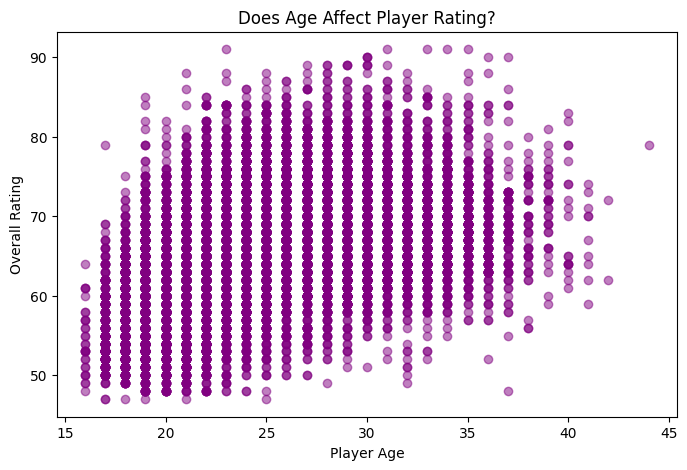

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Age'], df['Overall'], alpha=0.5, color='purple')
plt.xlabel('Player Age')
plt.ylabel('Overall Rating')
plt.title('Does Age Affect Player Rating?')
plt.show()

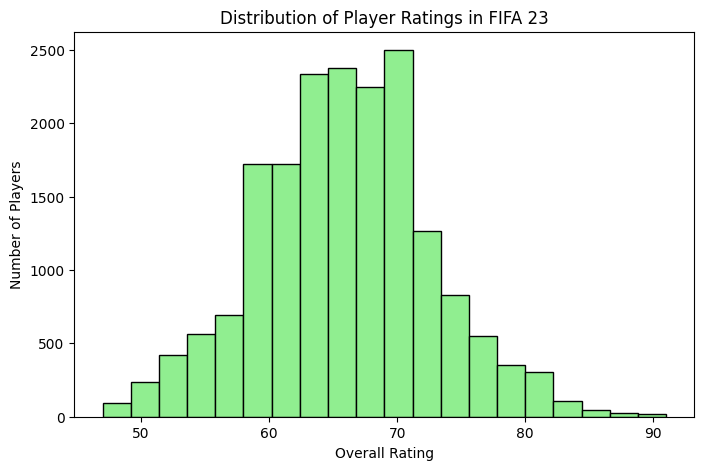

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['Overall'], bins=20, color='lightgreen', edgecolor='black')
plt.xlabel('Overall Rating')
plt.ylabel('Number of Players')
plt.title('Distribution of Player Ratings in FIFA 23')
plt.show()